<ipython-input-5-d17d2f43d09e>:6: RuntimeWarning: overflow encountered in double_scalars
  return -1000 * y + 3000 - 2000 * np.exp(-t)
<ipython-input-5-d17d2f43d09e>:19: RuntimeWarning: invalid value encountered in double_scalars
  y[i] = y[i-1] + h * f(t[i-1], y[i-1])


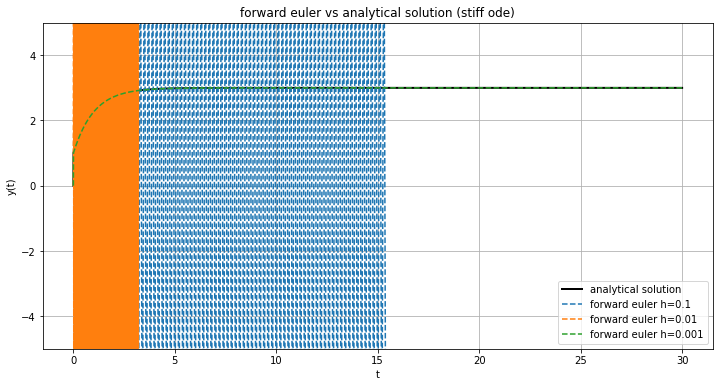

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# stiff ode
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

# exact solution
def exact(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

# forward euler method
def forward_euler(h, t_start, t_end, y0):
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(1, len(t)):
        y[i] = y[i-1] + h * f(t[i-1], y[i-1])

    return t, y

# parameters
t_start = 0
t_end = 30
y0 = 0

h_values = [0.1, 0.01, 0.001]

# plotting
plt.figure(figsize=(12, 6))

t_exact = np.linspace(t_start, t_end, 10000)
plt.plot(t_exact, exact(t_exact), 'k-', linewidth=2, label='analytical solution')

# run for each h
for h in h_values:
    t, y = forward_euler(h, t_start, t_end, y0)
    y_clipped = np.clip(y, -10, 10)
    plt.plot(t, y_clipped, label=f'forward euler h={h}', linestyle='--')

plt.title("forward euler vs analytical solution (stiff ode)")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.ylim(-5, 5) 
plt.legend()
plt.grid(True)
plt.show()